# Reproducing across laboratories

A screen at scale comes from more than one laboratory. This page uses JUMP-Target-2, the plate the JUMP
consortium {cite:p}`Chandrasekaran_2023` ran at every participating laboratory, so any difference between two
copies of it is technical.

JUMP calls a participating laboratory a source, and this page uses that column throughout: `Metadata_Source`,
with values from `source_2` to `source_13`. In a CellProfiler export, `Metadata_Site` is a field of view inside
a well, which this page does not use.

For Harmony, retrieval and iLISI disagree.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

## JUMP-Target-2

`mt.ds.jump_target2()` downloads one TARGET2 plate from each of the eleven sources that ran it,
and joins the JUMP annotation onto them. The plate map is identical at every source, and source_9
runs it four times over on a 1536-well plate; only the laboratory differs.

In [2]:
jump = mt.ds.jump_target2()
{
    "shape": jump.shape,
    "sources": jump.obs["Metadata_Source"].value_counts().to_dict(),
    "perturbations": int(jump.obs["Metadata_Perturbation"].nunique()),
    "control wells": int(jump.obs["Metadata_Control"].sum()),
}

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'shape': (5374, 3616),
 'sources': {'source_9': 1536,
  'source_10': 384,
  'source_13': 384,
  'source_3': 384,
  'source_4': 384,
  'source_5': 384,
  'source_6': 384,
  'source_7': 384,
  'source_8': 384,
  'source_11': 383,
  'source_2': 383},
 'perturbations': 302,
 'control wells': 898}

The perturbation annotation comes from the JUMP metadata repository, joined by `mt.io.read_jump`; see
[Published profiles and JUMP](../data/profiles.ipynb).

## The same pipeline

The recipe does not change for data from eleven laboratories.

In [3]:
mt.pp.normalize(jump, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(jump, na_cutoff=0.0)
jump = mt.pp.subset_features(jump)

{
    "features kept": jump.n_vars,
    "control wells per source": jump.obs.groupby("Metadata_Source", observed=True)["Metadata_Control"].sum().to_dict(),
}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/1507613305.py:1: UserWarning: 111 of 3616 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(jump, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'features kept': 603,
 'control wells per source': {'source_10': 64,
  'source_11': 64,
  'source_13': 64,
  'source_2': 65,
  'source_3': 64,
  'source_4': 64,
  'source_5': 64,
  'source_6': 65,
  'source_7': 64,
  'source_8': 64,
  'source_9': 256}}

## The batch metrics

`mt.metrics.evaluate_correction` runs the batch metrics and says which direction is better
for each.

In [4]:
sc.pp.pca(jump, n_comps=30)
mt.metrics.evaluate_correction(jump, label_key="Metadata_Perturbation", batch_key="Metadata_Source").round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.321,higher
1,silhouette_batch,X_pca,Metadata_Source,0.863,higher
2,ilisi,X_pca,Metadata_Source,2.765,higher
3,clisi,X_pca,Metadata_Perturbation,8.910,lower
4,pc_regression,X_pca,Metadata_Source,0.010,lower


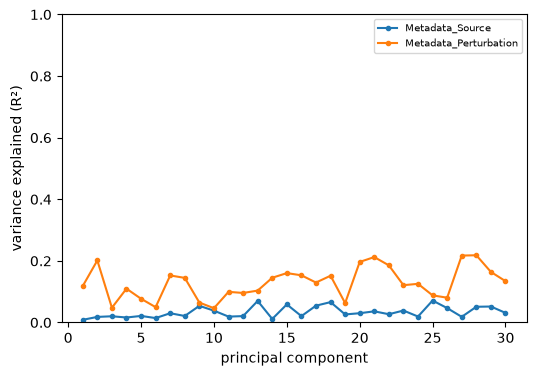

In [5]:
ax = mt.pl.batch_variance(jump, keys=["Metadata_Source", "Metadata_Perturbation"])
plt.show()

## Cross-source retrieval

Batch metrics ask whether the sites mix. A screen needs to know whether the same compound, run
at different sites, produces the same profile. That is a retrieval task, with `pos_sameby` set to the
perturbation and `pos_diffby` to the source.

The next cell computes the baseline, three corrections and an ICC feature filter.

In [6]:
def cross_source_map(adata, use_rep=None):
    """Mean average precision for retrieving a compound across sites."""
    treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
    mt.tl.map(
        treated,
        pos_sameby=["Metadata_Perturbation"],
        pos_diffby=["Metadata_Source"],
        neg_diffby=["Metadata_Perturbation"],
        use_rep=use_rep,
        null_size=500,
        seed=0,
    )
    table = treated.uns["mantispy"]["map"]
    return round(float(table["mean_average_precision"].mean()), 3), int(table["below_corrected_p"].sum())


n_treated = int(jump.obs.loc[~jump.obs["Metadata_Control"].to_numpy(), "Metadata_Perturbation"].nunique())
variants = {"per-plate normalize only": jump}

per_source = jump.copy()
mt.pp.sphere(per_source, method="ZCA-cor", reference="negcon", by="Metadata_Source")
variants["+ sphere per source"] = per_source

pooled = jump.copy()
mt.pp.sphere(pooled, method="ZCA-cor", reference="negcon")
variants["+ sphere pooled controls"] = pooled

regressed = jump.copy()
mt.pp.regress_out(regressed, keys=["Metadata_Source"], by=None)
variants["+ regress out source"] = regressed

reproducible = jump.copy()
mt.pp.feature_reproducibility(reproducible, groupby="Metadata_Perturbation", min_icc=0.2)
reproducible = reproducible[:, reproducible.var["icc_selected"].to_numpy()].copy()
variants["+ keep ICC > 0.2"] = reproducible

pd.DataFrame(
    [
        {"pipeline": name, "features": adata.n_vars, "cross-source mAP": score, f"significant of {n_treated}": count}
        for name, adata in variants.items()
        for score, count in [cross_source_map(adata)]
    ]
)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:21: UserWarning: sphering is fitted on 64 reference rows for 603 features. With fewer rows than features the covariance is singular and the transform amplifies noise. Select fewer features first, or use more controls.
  mt.pp.sphere(per_source, method="ZCA-cor", reference="negcon", by="Metadata_Source")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:21: UserWarning: sphering is fitted on 65 reference rows for 603 features. With fewer rows than features the covariance is singular and the transform amplifies noise. Select fewer features first, or use more controls.
  mt.pp.sphere(per_source, method="ZCA-cor", reference="negcon", by="Metadata_Source")


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:21: UserWarning: sphering is fitted on 256 reference rows for 603 features. With fewer rows than features the covariance is singular and the transform amplifies noise. Select fewer features first, or use more controls.
  mt.pp.sphere(per_source, method="ZCA-cor", reference="negcon", by="Metadata_Source")


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


,pipeline,features,cross-source mAP,significant of 301
0,per-plate normalize only,603,0.021,79
1,+ sphere per source,603,0.021,117
2,+ sphere pooled controls,603,0.008,0
3,+ regress out source,603,0.004,0
4,+ keep ICC > 0.2,253,0.028,122


In [7]:
# The batch metrics again, after sphering per source.
sphered = variants["+ sphere per source"].copy()
sc.pp.pca(sphered, n_comps=30)
mt.metrics.evaluate_correction(
    sphered, reps=("X_pca",), label_key="Metadata_Perturbation", batch_key="Metadata_Source"
).round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.387,higher
1,silhouette_batch,X_pca,Metadata_Source,0.895,higher
2,ilisi,X_pca,Metadata_Source,5.181,higher
3,clisi,X_pca,Metadata_Perturbation,4.753,lower
4,pc_regression,X_pca,Metadata_Source,0.013,lower


Compare that table with the metrics above.

Sphering per source improves every batch metric except the variance explained by source, and here
retrieval agrees: the mAP holds, and 117 compounds are recovered above chance instead of 79.
Sphering on the pooled controls and regressing out the source recover none. Keeping the features
whose replicates agree, which is not a batch correction, recovers the most.

Judge a correction by the retrieval the screen needs. The mixing metrics describe the batches,
not whether the biology survived.

With one plate per site, there are 64 or 65 control wells per site (256 at source_9) against 603
features, so every covariance-based correction here is underdetermined. With twenty plates per
site the result could differ.

## What the consortium's recipe does

JUMP has three recipes, and the perturbation type decides which one applies.
`jump-profiling-recipe` names them in its configs. For compounds, which TARGET-2 contains,
`compound.json` specifies

```
profiles_var_mad_int_featselect_harmony
```

that is, variance-based feature selection, MAD normalization against the negative controls, the rank
inverse normal transform, feature selection and Harmony. The ORF and CRISPR branches use a
different pipeline, `profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony`, which
adds well position correction, cell count regression, outlier removal and sphering.

Sphering is not in the compound pipeline. The two steps of the compound pipeline that the
comparison above does not include are covered below, and both behave differently from the
corrections in that table.

`pp.rank_int` is the rank inverse normal transform. Each feature's values are replaced by
their normal scores within a plate, so only the ordering of the wells is kept and the scale is
discarded. Every feature ends up standard normal by construction, which is a strong assumption
about your data, so check what it costs.

In [8]:
inted = jump.copy()
mt.pp.rank_int(inted, by="Metadata_Plate")

# The reference implementation ranks each feature over the whole screen; ranking within a
# plate additionally removes any plate-level difference in the shape of the distribution.
globally = jump.copy()
mt.pp.rank_int(globally)

inted_icc = inted.copy()
mt.pp.feature_reproducibility(inted_icc, groupby="Metadata_Perturbation", min_icc=0.2)
inted_icc = inted_icc[:, inted_icc.var["icc_selected"].to_numpy()].copy()

pd.DataFrame(
    [
        {"pipeline": name, "features": adata.n_vars, "cross-source mAP": score, f"significant of {n_treated}": count}
        for name, adata in [
            ("per-plate normalize only", jump),
            ("+ rank INT, ranked globally", globally),
            ("+ rank INT, ranked per plate", inted),
            ("+ rank INT per plate, then ICC > 0.2", inted_icc),
        ]
        for score, count in [cross_source_map(adata)]
    ]
)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


,pipeline,features,cross-source mAP,significant of 301
0,per-plate normalize only,603,0.021,79
1,"+ rank INT, ranked globally",603,0.023,113
2,"+ rank INT, ranked per plate",603,0.033,126
3,"+ rank INT per plate, then ICC > 0.2",61,0.034,150


Ranking per plate helps more than any correction above, and the ICC filter adds to it on only 61
features.
Ranking globally does not.

Where you rank matters. The reference implementation ranks each feature over the whole
screen, which is the `by=None` default. Ranking within each plate works markedly better here,
because it also removes plate-to-plate differences in the shape of a
feature's distribution, which with one plate per site are the differences between sites.

The transform discards magnitude, and distance from the controls depends on magnitude, so
check the effect on activity as well:

In [9]:
def activity(adata):
    """Phenotypic activity: can each compound be told from the negative controls?"""
    scratch = adata.copy()
    mt.tl.map(scratch, mode="activity", null_size=500, seed=0)
    table = scratch.uns["mantispy"]["map"]
    return round(float(table["mean_average_precision"].mean()), 3), int(table["below_corrected_p"].sum())


{"per-plate normalize only": activity(jump), "+ rank INT": activity(inted)}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/1587307392.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(scratch, mode="activity", null_size=500, seed=0)


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/1587307392.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(scratch, mode="activity", null_size=500, seed=0)


{'per-plate normalize only': (0.249, 110), '+ rank INT': (0.289, 117)}

Here it costs nothing, and activity rises too. That need not generalize: this is one plate per
source and 603 features. The
outcome depends on the screen, so measure both before adopting it.

## Harmony, and a metric that disagrees with retrieval

`pp.harmony` ranked in the top three in every scenario of the batch-correction benchmark
{cite:p}`Arevalo_2024`, as did Seurat RPCA, and is the last step of the recipe.
It works on an embedding rather than on features (it alternates soft clustering and
per-cluster linear correction), so it returns a corrected `obsm`, not a corrected `X`. It needs the optional extra,
`pip install 'mantispy[harmony]'`. Its result moves with the seed and the row order;
[Learned embeddings against CellProfiler](learned_embeddings.ipynb) measures how much the seed moves it.

In [10]:
harmonised = jump.copy()  # carries the X_pca from above
mt.pp.harmony(harmonised, batch_key="Metadata_Source", use_rep="X_pca")

mt.metrics.evaluate_correction(
    harmonised, reps=("X_pca", "X_harmony"), label_key="Metadata_Perturbation", batch_key="Metadata_Source"
).round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.321,higher
1,silhouette_batch,X_pca,Metadata_Source,0.863,higher
2,ilisi,X_pca,Metadata_Source,2.765,higher
3,clisi,X_pca,Metadata_Perturbation,8.910,lower
4,pc_regression,X_pca,Metadata_Source,0.010,lower
5,silhouette_label,X_harmony,Metadata_Perturbation,0.324,higher
6,silhouette_batch,X_harmony,Metadata_Source,0.890,higher
7,ilisi,X_harmony,Metadata_Source,1.221,higher
8,clisi,X_harmony,Metadata_Perturbation,8.941,lower
9,pc_regression,X_harmony,Metadata_Source,0.013,lower


In [11]:
def centroid_spread(embedding):
    """Mean distance of the site centroids from their mean."""
    centroids = pd.DataFrame(embedding).groupby(harmonised.obs["Metadata_Source"].to_numpy()).mean()
    return round(float(np.linalg.norm(centroids - centroids.mean(), axis=1).mean()), 1)


{
    key: {
        "site centroid spread": centroid_spread(harmonised.obsm[key]),
        "cross-source mAP": cross_source_map(harmonised, use_rep=key),
    }
    for key in ("X_pca", "X_harmony")
}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2805155733.py:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


{'X_pca': {'site centroid spread': 418.0, 'cross-source mAP': (0.016, 44)},
 'X_harmony': {'site centroid spread': 383.5, 'cross-source mAP': (0.018, 50)}}

Harmony pulls the site centroids 8% closer and raises cross-source retrieval slightly, yet
iLISI falls from 2.765 to 1.221.

iLISI asks whether a well's nearest neighbors come from several sites. Harmony aligns the sites
globally without mixing local neighborhoods, so a well stays surrounded by wells from its own
site while the site clouds move together. Both observations hold, and retrieval is the one that
answers the screen's question.

harmonypy can report convergence and return the embedding unchanged. `pp.harmony` compares its
output with its input and warns when they are identical, so that uncorrected numbers do not
pass unnoticed through the rest of the pipeline.

In [12]:
treated = jump[~jump.obs["Metadata_Control"].to_numpy()].copy()
mt.tl.map(
    treated,
    pos_sameby=["Metadata_Perturbation"],
    pos_diffby=["Metadata_Source"],
    neg_diffby=["Metadata_Perturbation"],
    null_size=500,
    seed=0,
)
sc.pp.pca(treated, n_comps=30)
mt.metrics.evaluate_correction(
    treated, label_key="Metadata_Perturbation", batch_key="Metadata_Source", map_key="map"
).round(3)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/2782924150.py:2: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  mt.tl.map(


,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.328,higher
1,silhouette_batch,X_pca,Metadata_Source,0.864,higher
2,ilisi,X_pca,Metadata_Source,2.657,higher
3,clisi,X_pca,Metadata_Perturbation,12.685,lower
4,pc_regression,X_pca,Metadata_Source,0.012,lower
5,mean_average_precision,X,Metadata_Perturbation,0.021,higher


The last table is `evaluate_correction` with `map_key=` set, so the retrieval number appears
in the same table as the mixing metrics. Its `representation` reads `X`, the matrix `tl.map`
scored, not the `X_pca` of the rows above it. It runs on the treated wells only, which is why
cLISI reads 12.7 here against 8.9 in the first table on this page: dropping 898 DMSO wells
with the same label makes every neighborhood more label-diverse. Compare rows within a table, not
across tables built on different rows.

## Which compounds reproduce across sites?

The results above are aggregates: one mAP for the screen, one LISI per representation. Follow-up
work needs to know which compounds reproduced, which the page has not yet shown.

`tl.transport` answers that. It computes each perturbation's effect as its profile minus the
control centroid of its own setting, so a baseline offset does not count as disagreement, and
measures how well those effect vectors agree across settings. `by=` takes a list from coarsest
to finest level, and each pair of plates is assigned to the coarsest level at which the two
differ, so every comparison belongs to exactly one level.

With one plate per laboratory, as so far, laboratory and plate effects are the same comparison
and cannot be separated. The next cell loads twelve of the 141 plates `jump_target2` pins: three
sources, two batches each, two plates per batch.

This section uses only the per-plate `mad_robustize` normalization from earlier, without
`rank_int`, Harmony or the other corrections evaluated above. Its numbers are an uncorrected
baseline on a different set of plates and are not comparable with the eleven-plate mAP values
earlier on this page.

In [13]:
hierarchy = mt.ds.jump_target2(
    plates=["JCPQC051", "JCPQC052", "JCPQC053", "JCPQC054"]
    + ["BR00121438", "BR00121439", "BR00126113", "BR00126114"]
    + ["110000294936", "110000296682", "110000296339", "110000296356"]
)
mt.pp.normalize(hierarchy, method="mad_robustize", by="Metadata_Plate", reference="negcon")
hierarchy = hierarchy[:, ~hierarchy.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(hierarchy, na_cutoff=0.0)
hierarchy = mt.pp.subset_features(hierarchy)

mt.tl.transport(hierarchy, by=["Metadata_Source", "Metadata_Batch", "Metadata_Plate"])
by_level = hierarchy.uns["mantispy"]["transport"]
by_level.groupby("level", observed=True).agg(
    compounds=("group", "size"),
    agreement=("agreement", "median"),
    reproduce=("transports", "sum"),
).round(3).reindex(["Metadata_Plate", "Metadata_Batch", "Metadata_Source"])

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86473/410595559.py:6: UserWarning: 67 of 3616 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(hierarchy, method="mad_robustize", by="Metadata_Plate", reference="negcon")


,compounds,agreement,reproduce
level,,,
Metadata_Plate,301,0.475,75
Metadata_Batch,301,0.365,75
Metadata_Source,301,0.134,61


Read the table row by row. A compound's effect agrees at +0.475 between two plates of one
batch, at +0.365 between batches of one laboratory, and at +0.134 between laboratories. Each
step up the hierarchy lowers agreement, and the step between laboratories costs about twice
as much as the step between batches.

A single aggregate cross-source mAP shows that the sites disagree, but not whether to fix
plate handling or the protocol. The gap between levels does.

The `reproduce` column counts the compounds whose agreement beats the null at q < 0.05. The
null uses every mismatched pair of compounds at that level instead of a sample. A sampled null
would not give Benjamini-Hochberg enough resolution: its smallest possible p-value is one over
the number of draws, so the count would reflect the number of draws rather than the screen.

`pl.setting_agreement`, in the figure below, reads the same effect vectors by plate instead of
by compound: it shows which of the twelve plates agree with each other. Annotating by source
draws a line at each laboratory boundary, so a laboratory that disagrees with itself appears as
a broken block. Its cells are an activity-weighted mean over compounds, while the table's
per-level number is an unweighted median, so the heatmap reads higher than the table for the
same pair of settings. Use it to see which settings differ from each other, not to compare
absolute levels with the table.

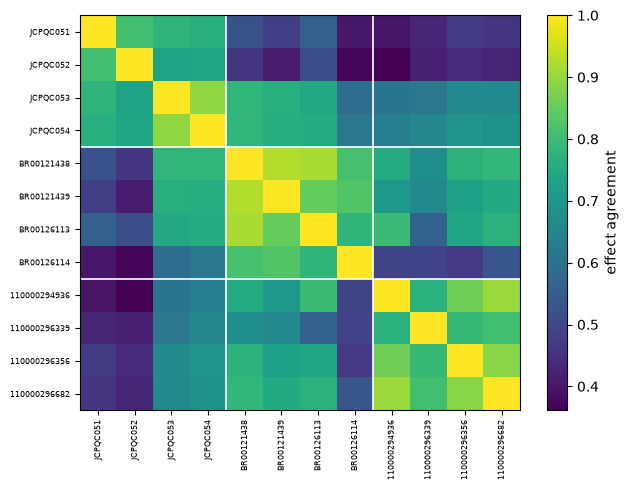

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5))
mt.pl.setting_agreement(hierarchy, by="Metadata_Source", ax=ax)
fig.tight_layout()
plt.show()

## Summary

- "Site" is ambiguous in this field. JUMP's source is a laboratory; CellProfiler's
  `Metadata_Site` is a field of view.
- Judge a correction by the question your screen asks. On this data iLISI
  and retrieval disagreed about Harmony, and the corrections that pooled the sites removed
  the biological signal.
- Reproducibility has levels. `tl.transport` separates them, and the gap between two levels
  is more actionable than either value alone. It is an observational measure: it supports
  "this effect did not reproduce at the other site", but not "this effect would have been
  *x* at the other site".

Next: [Learned embeddings against CellProfiler](learned_embeddings.ipynb), the same question asked of six
feature sets.